<a href="https://colab.research.google.com/github/Aarav2123/ece-python-fundamentals/blob/notebooks/RC_Visualizer_Week_3_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What is the Resistance(in Ohms)?: 1000
What is the Capacitance(in Farads)?: 1e-7
What is the Signal Frequency(in Hertz)?: 100
What is the Signal Voltage(in Volts)?: 5

      RC LOW-PASS FILTER RESULTS        
 Cutoff Frequency (fc) : 1591.55 Hz
 Voltage Gain (Av)     : 0.998
 Gain in Decibels      : -0.02 dB
 Output Voltage (Vout) : 4.99 V
 Phase Shift           : -3.60°
----------------------------------------
Signal Region: Passband (Minimal Attenuation)


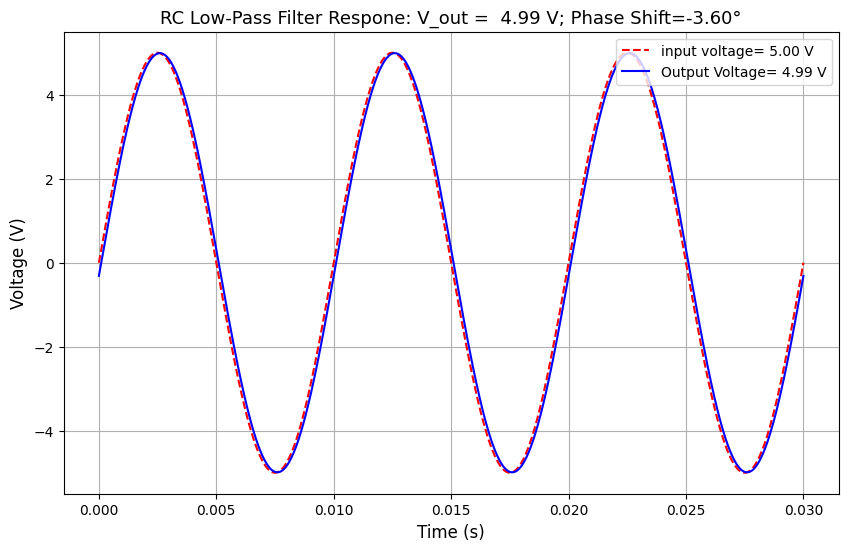

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt


def inputs():
    while True:
      R=float(input("What is the Resistance(in Ohms)?: "))
      if R<=0:
        print("Error, Resistance has to be a positive")
      else:
        break

    while True:
      C=float(input("What is the Capacitance(in Farads)?: "))
      if C<=0:
        print("Error, Capacitance has to be a positive")
      else:
        break

    while True:
      F=float(input("What is the Signal Frequency(in Hertz)?: "))
      if F<=0:
        print("Error, Frequency has to be a positive")
      else:
        break

    V=float(input("What is the Signal Voltage(in Volts)?: "))
    if abs(V)>12:
        print("WARNING! Input exceeds standard 12V breadboard/Op-Amp rating")

    return R, C, F, V

def RC_Low_Pass_Filter_Visualizer():


  R, C, F, V = inputs()

  Cutoff_Frequency=1/(2*math.pi*R*C)
  Voltage_Gain=1/math.sqrt(1+(F/Cutoff_Frequency)**2)
  Gain_Decibels=20*math.log10(Voltage_Gain)
  Output_Voltage=V*Voltage_Gain
  Phase_Shift=-math.atan(F/Cutoff_Frequency)
  Phase_Shift_Degrees=math.degrees(Phase_Shift)

  print("\n" + "="*40,"      RC LOW-PASS FILTER RESULTS        ","="*40, sep="\n")
  print(f" Cutoff Frequency (fc) : {Cutoff_Frequency:.2f} Hz")
  print(f" Voltage Gain (Av)     : {Voltage_Gain:.3f}")
  print(f" Gain in Decibels      : {Gain_Decibels:.2f} dB")
  print(f" Output Voltage (Vout) : {Output_Voltage:.2f} V")
  print(f" Phase Shift           : {Phase_Shift_Degrees:.2f}°")
  print("-"*40)


  if math.isclose(F,Cutoff_Frequency, rel_tol=0.05):
      print("Signal Region: Cuttoff Frequency (-3dB Corner Point)")
  elif F<Cutoff_Frequency:
      print("Signal Region: Passband (Minimal Attenuation)")
  else:
      print("Signal Region: Stopband (High-Frequency Attenuation)")

  print("="*40)

  T=1/F
  t = np.linspace(0, 3*T, 1000)

  v_in = V*np.sin(2*np.pi*F*t)
  v_out = Output_Voltage*np.sin(2*np.pi*F*t + Phase_Shift)

  plt.figure(figsize=(10,6))

  plt.plot(t, v_in, label= f"Input Voltage={V: .2f} V", color="red", linestyle="--")
  plt.plot(t, v_out, label = f"Output Voltage={Output_Voltage: .2f} V", color = "blue" )

  plt.xlabel("Time (s)", fontdict={"fontsize":12})
  plt.ylabel("Voltage (V)", fontdict={"fontsize":12})
  plt.title(f"RC Low-Pass Filter Respone: V_out = {Output_Voltage: .2f} V; Phase Shift={Phase_Shift_Degrees: .2f}°", fontsize=13)
  plt.legend(loc="upper right")
  plt.grid(True)

  plt.savefig("RC_Visualizer.png", dpi=300,bbox_inches="tight")
  plt.show()

RC_Low_Pass_Filter_Visualizer()